In [3]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten,Dense,Input
from tensorflow.keras.utils import to_categorical

In [4]:
#加载并预处理数据
#加载CIFAR-10数据集
(x_train,y_train),(x_test,y_test) = cifar10.load_data()

#1.数据归一化:将像素值从0-255缩放到0-1
x_train = x_train / 255.0
x_test = x_test / 255.0

#查看数据形状(验证预处理是否正确)
print("训练集形状:",x_train.shape) #应输入(50000,32,32,3)
print("测试集形状:",x_test.shape) #应输出(10000,32,32,3)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 8201s 48us/step
训练集形状: (50000, 32, 32, 3)
测试集形状: (10000, 32, 32, 3)


D:\编程教程\Python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 31867 (\N{CJK UNIFIED IDEOGRAPH-7C7B}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\编程教程\Python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 21035 (\N{CJK UNIFIED IDEOGRAPH-522B}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\编程教程\Python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 38738 (\N{CJK UNIFIED IDEOGRAPH-9752}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\编程教程\Python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 34521 (\N{CJK UNIFIED IDEOGRAPH-86D9}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\编程教程\Python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 21345 (\N{CJK UNIFIED IDEOGRAPH-5361}) missing from font(s) DejaVu Sans.
  func(*args, **kwargs)
D:\编程教程\Python\Lib\site-packages\IPython\core\events.py:82: UserWarning: Glyph 36710 (\N{CJK UNIFIED IDEOGRAPH-8F66}) mi

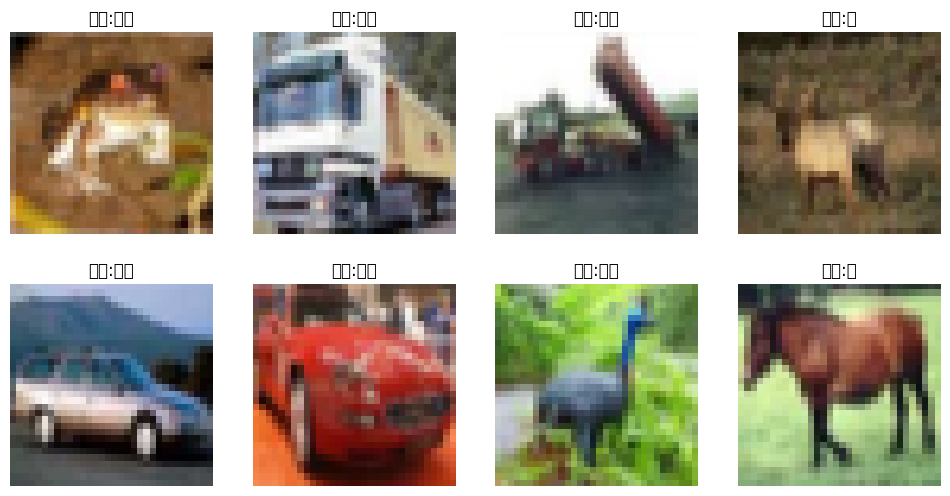

In [7]:
#展示的图片
cifar10_classes = ['飞机','汽车','鸟类','猫','鹿','狗','青蛙','马','船','卡车']
# 设置展示的图片数量(比如8张)
num_images = 8
plt.figure(figsize=(12,6))#画布大小
for i in range(num_images):
    #创建子图:2行4列，第i+1个位置
    plt.subplot(2,4,i+1)
    #显示图片(x_train[i]是32*32*3的图像)
    plt.imshow(x_train[i])
    #获取对应标签(y_train[i][0]是原始标签索引)
    label = cifar10_classes[y_train[i][0]]
    # 设置图片标题(类别名称)
    plt.title(f'类别:{label}')
    #隐藏坐标轴(更美观)
    plt.axis('off')

In [8]:
y_train = to_categorical(y_train,10)
y_test = to_categorical(y_test,10)

In [9]:
y_train

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 0., 0., ..., 0., 0., 1.],
       ...,
       [0., 0., 0., ..., 0., 0., 1.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.]])

In [11]:
#构建卷积神经网络
model = Sequential([
    #指定单个图像的宽度 高度 通道
    Input(shape=(32,32,3)),
    #卷积操作
    Conv2D(32,(3,3),activation='relu'),
    #最大池化层
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(512,activation='relu'),

    Dense(10,activation='softmax')
])

In [12]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 30, 30, 32)          │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 15, 15, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 13, 13, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 128)           │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_4 (MaxPooling2D)       │ (None, 2, 2, 128)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 512)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │         262,656 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │           5,130 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 361,034 (1.38 MB)

 Trainable params: 361,034 (1.38 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
#编译模型
model.compile(
    optimizer='adam',
    # cateforical_crossentropy
    loss='categorical_crossentropy',
    metrics=['accuracy']#评估使用准确率
)    

In [15]:
#训练模型
model.fit(x_train,y_train,epochs=10,batch_size=64,validation_split=0.2
)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 36s 44ms/step - accuracy: 0.4231 - loss: 1.5704 - val_accuracy: 0.5215 - val_loss: 1.3293
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.5728 - loss: 1.2022 - val_accuracy: 0.5987 - val_loss: 1.1355
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.6331 - loss: 1.0400 - val_accuracy: 0.6370 - val_loss: 1.0274
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.6788 - loss: 0.9196 - val_accuracy: 0.6520 - val_loss: 1.0030
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 48ms/step - accuracy: 0.7144 - loss: 0.8139 - val_accuracy: 0.6793 - val_loss: 0.9214
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.7423 - loss: 0.7353 - val_accuracy: 0.6901 - val_loss: 0.9071
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 43ms/step - accuracy: 0.7683 - loss: 0.6605 - val_accuracy: 0.7082 - val_loss: 0.8720
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 27s 43ms/step - accuracy: 0.7897 - loss: 0.5972 - 

In [16]:
model.evaluate(x_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.7029 - loss: 0.9498


[0.9498344659805298, 0.7028999924659729]

In [17]:
#进行预测
prediction = model.predict(x_test)
prediction

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step


array([[2.02662149e-03, 9.08568967e-04, 6.33268477e-03, ...,
        7.33813096e-04, 1.48713347e-02, 1.04674065e-04],
       [8.96346930e-04, 1.31185994e-01, 7.37694517e-10, ...,
        3.35596384e-10, 8.67908478e-01, 9.21380797e-06],
       [2.70328969e-02, 6.97993040e-02, 2.48846864e-05, ...,
        2.72143534e-05, 8.90636742e-01, 1.20408647e-02],
       ...,
       [1.07658522e-08, 9.38827213e-07, 4.95154585e-04, ...,
        2.18760176e-03, 9.46679302e-06, 2.43970817e-07],
       [8.94267359e-05, 9.99875188e-01, 9.13635995e-06, ...,
        5.02271087e-06, 7.42462532e-07, 2.12769874e-06],
       [1.04373346e-08, 5.65545215e-11, 1.53697347e-05, ...,
        9.95487511e-01, 9.88493731e-10, 7.35685124e-11]], dtype=float32)

In [18]:
np.argmax(prediction[2])

8

In [19]:
#保存模型
model.save('cifar10_model.keras')

In [20]:
#使用训练好的模型来进行预测
import tensorflow as tf
new_model = tf.keras.models.load_model('cifar10_model.keras')

In [21]:
#使用测试集的一些数据来进行预测
x_sample = x_test[:10]
y_sample = y_test[:10]

In [22]:
#模型预测
new_prediction = new_model.predict(x_sample)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


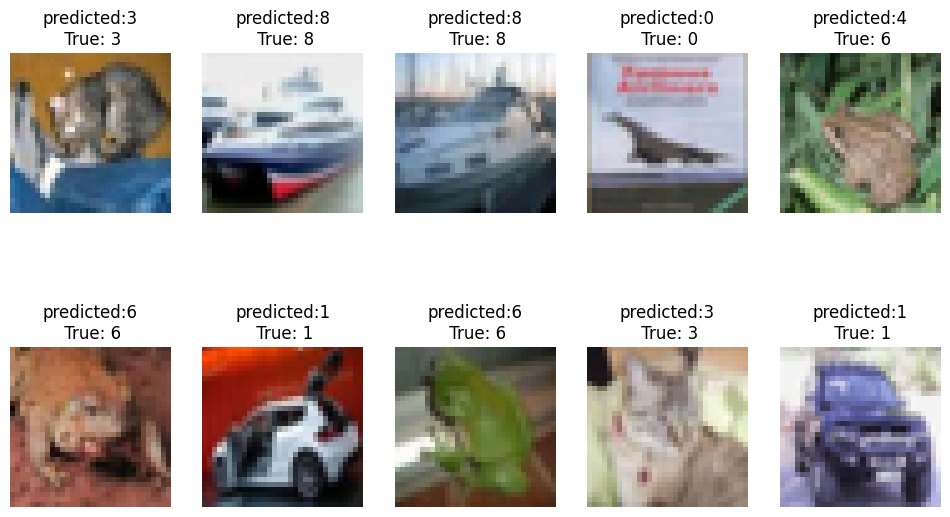

In [28]:
#可视化 每张图片 以及预测结果
plt.figure(figsize=(12,7))
for i in range(10):
 plt.subplot(2,5,i+1)
 plt.imshow(x_sample[i])
 plt.title(f'predicted:{np.argmax(new_prediction[i])}\n True: {np.argmax(y_sample[i])}')
 plt.axis('off')   